# (03) Stages MNIST: fwd(0+5)

host = ```yoru```, device = ```cuda:1```

**Motivation**:  <br>

- $\Delta \theta = 2.0$
- $T_\text{train} = 32$
- $T_\text{tbptt} = 32$

4 stages, geometric, balanced time

tighter decoder sigma clamp (`0.8` instead of `1.15`)

In [1]:
# HIDE CODE


project_name = '_TemporalSC'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from figures.convergence import plot_convergence
from main.config_defaults import default_configs
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## A 4 stage model

- `t_train = 16`
- `t_tbptt = 8`
- `n_stages = 4`

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST+rotate', model_type, 'ngd|lin')

cfg_vae['t_train'] = 16
cfg_vae['t_tbptt'] = 8
cfg_vae['n_stages'] = 4
cfg_vae['kl_beta'] = 1.0

cfg_vae['latent_channels'] = 192
cfg_vae['latent_pixels'] = 8
cfg_vae['latent_stride'] = 3

cfg_vae['fwd_ker_u'] = 0
cfg_vae['fwd_ker_z'] = 5

cfg_vae['feeder_cfg'] = {'max_delta_theta': 2.0}

cfg_tr['lr'] = 1e-3
cfg_tr['epochs'] = 100
cfg_tr['batch_size'] = 200

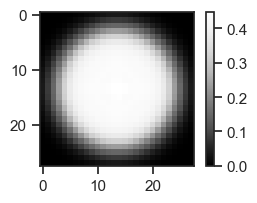

30000

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

sigma = tr.data_dependent_init(t_total=200, n_data_batches=5, data_batch_sz=5000)

imshow(sigma.squeeze(), cmap='Greys_r')
plt.colorbar()
plt.show()

tr.feeder_trn.n_iters

In [5]:
print(sorted(np.unique(tr.t_trains)))
print(collections.Counter(tr.t_trains))

[16, 32, 64, 128]

Counter({16: 16000, 32: 8000, 64: 4000, 128: 2000})

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  932.0 K   |
|     ———     |    ———     |
|    layer    |  932.0 K   |
+-------------+------------+

poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(0,5)_prob_<ngd|lin>
b200-ep100-lr(0.001)_temp(0.05)_gr(250)_(2025_09_04,21:38)

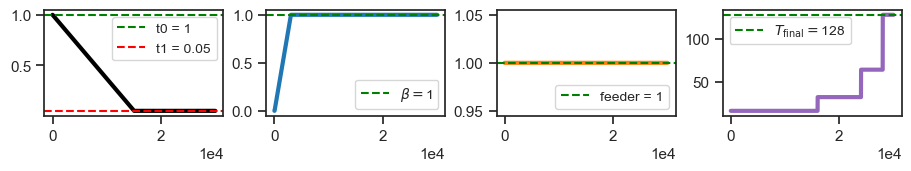

In [6]:
model.print()
tr.print()
tr.show_schedules()

In [7]:
model.layer.n_exp

tensor([50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50], device='cuda:1', dtype=torch.int32)

In [8]:
print(f"\n\n{tr.model.layer}\n\n{tr.model.layer.dec}\n")

PoissonLayer(latent_sz=(192, 8, 8), input_sz=(1, 28, 28), temp=1)

ConvDictionary(in_channels=192, out_channels=1, kernel_size=7, stride=3)

In [9]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  932.0 K   |
|     ———      |    ———     |
|    log_dt    |     1      |
|     dec      |   9.4 K    |
|   fwd_z.0    |  921.6 K   |
|    u_init    |    192     |
+--------------+------------+

In [10]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 16, 't_tbptt': 8, 'n_stages': 4, 'kl_beta': 1.0, 
'latent_channels': 192, 'latent_pixels': 8, 'latent_stride': 3, 'fwd_ker_u': 0, 'fwd_ker_z': 5, 'enc_type': 'ngd', 
'dec_type': 'lin', 'recon_mode': 'prob', 'dataset': 'MNIST+rotate', 'dataset_name': 'MNIST', 'feeder': 'rotate', 
'feeder_cfg': {'max_delta_theta': 2.0, 'theta_0': None, 'anneal_portion': 0.0}, 'input_sz': (1, 28, 28), 
'latent_sz': (192, 8, 8), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u': (4.0,), 'du': (4.0,), 
'dec': 0.8}, 'stochastic': True, 'optim_sigma': False, 'fit_sigma': True, 'fit_prior': True, 'fit_bias': False, 
'fit_dt': True, 'seed': 0, 'track_stats': False, 'base_dir': '/home/hadi/Projects/TemporalSC', 'data_dir': 
'/home/hadi/Datasets', 'runs_dir': 
'/home/hadi/Projects/TemporalSC/runs/poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(0,5)_prob_<ngd|lin>', 
'mods_dir': 
'/home/hadi/Projects/TemporalSC/models/poisson_MNIST+rotate_t-(16,8,4)_b-1_kms-(192,8,3)_fwd-(0,5)_prob_<ngd|lin>',
'results_dir': '/home/hadi/Projects/TemporalSC/results'}

{'lr': 0.001, 'epochs': 100, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.005, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 99.5, 'eta_min': 1e-07}, 'ema_rate': None, 'grad_clip': 250,
'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [11]:
comment = '_'.join([
    f"fwd:u{tr.model.cfg.fwd_ker_u}+z{tr.model.cfg.fwd_ker_z}",
    f"fit:{'dt' if tr.model.cfg.fit_dt else ''}+{'sig' if tr.model.cfg.fit_sigma else ''}",
    f"ClampDec-{tr.model.cfg.clamp_vals['dec']}",
    'datadepinit',
])
print(comment)

fwd:u0+z5_fit:dt+sig_ClampDec-0.8_datadepinit

In [12]:
tr.train(comment=comment)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 100, avg loss: 139.125: 100%|█████| 100/100 [14:15:18<00:00, 513.19s/it]


## observe:

4 stages (geometric): help or hurt?

Trying to reproduce these:

- (best fit) https://wandb.ai/yateslab/_TemporalSC/runs/dvyetrxh/overview
- (recent good fit with fwd(1+3)): https://wandb.ai/yateslab/_TemporalSC/runs/61a6a7yh?nw=nwuservafaii

In [13]:
print(model.layer.n_exp)

tensor([ 6, 25, 43, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44,
        44, 44], device='cuda:1', dtype=torch.int32)

100%|███████████████████████████████████| 5/5 [00:17<00:00,  3.57s/it]


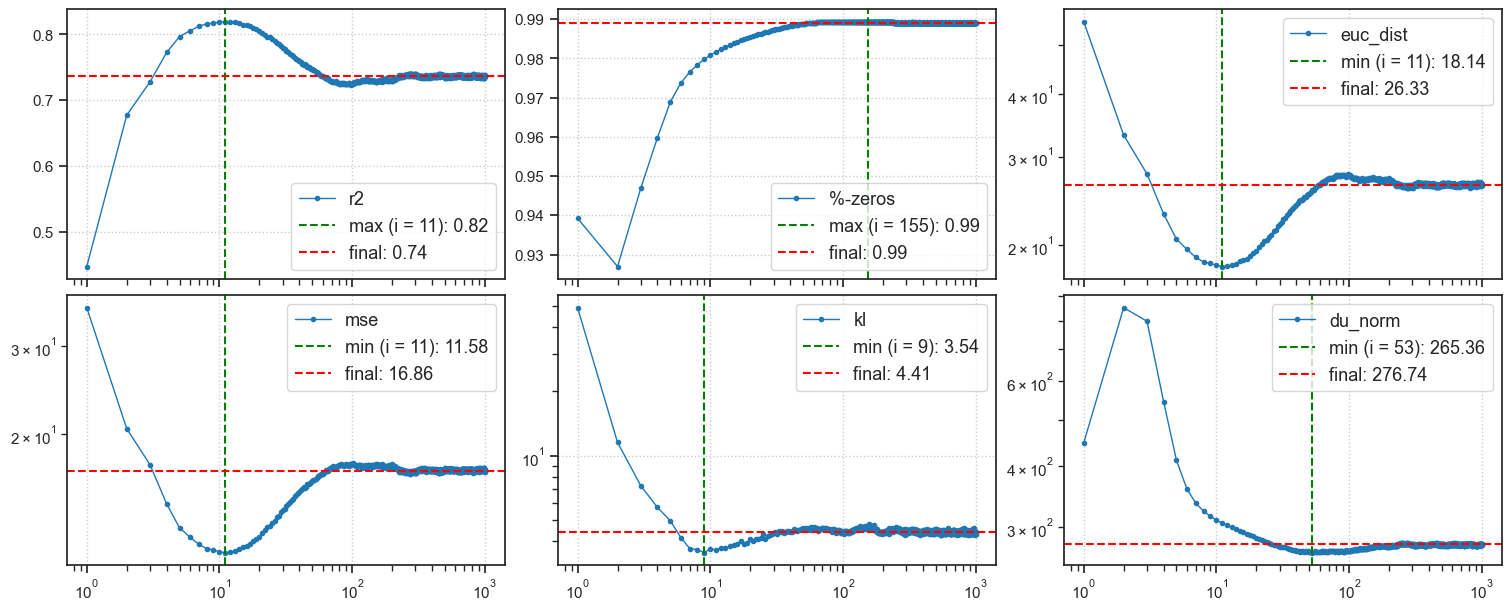

CPU times: user 18.9 s, sys: 36 ms, total: 18.9 s
Wall time: 18.9 s


In [14]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=5)
_ = plot_convergence(results=results, color='C0')

100%|█████████████████████████████████| 50/50 [02:59<00:00,  3.58s/it]


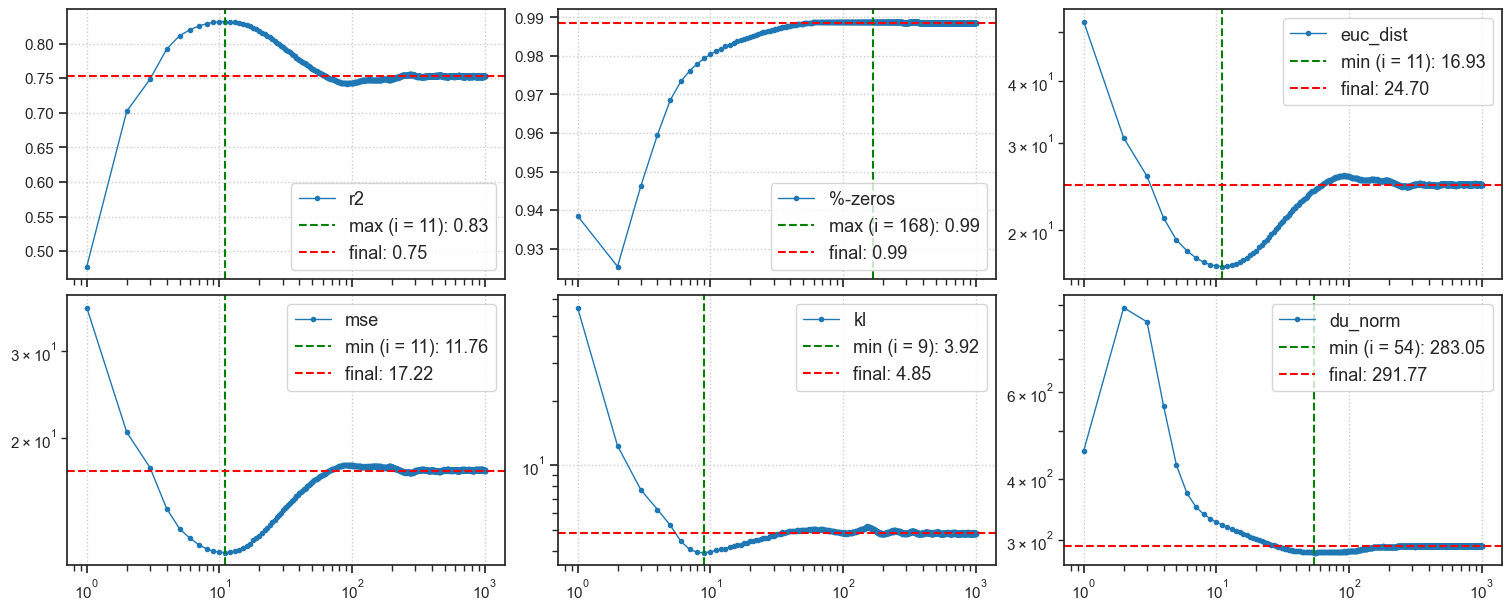

CPU times: user 3min, sys: 104 ms, total: 3min
Wall time: 3min


In [18]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='C0')

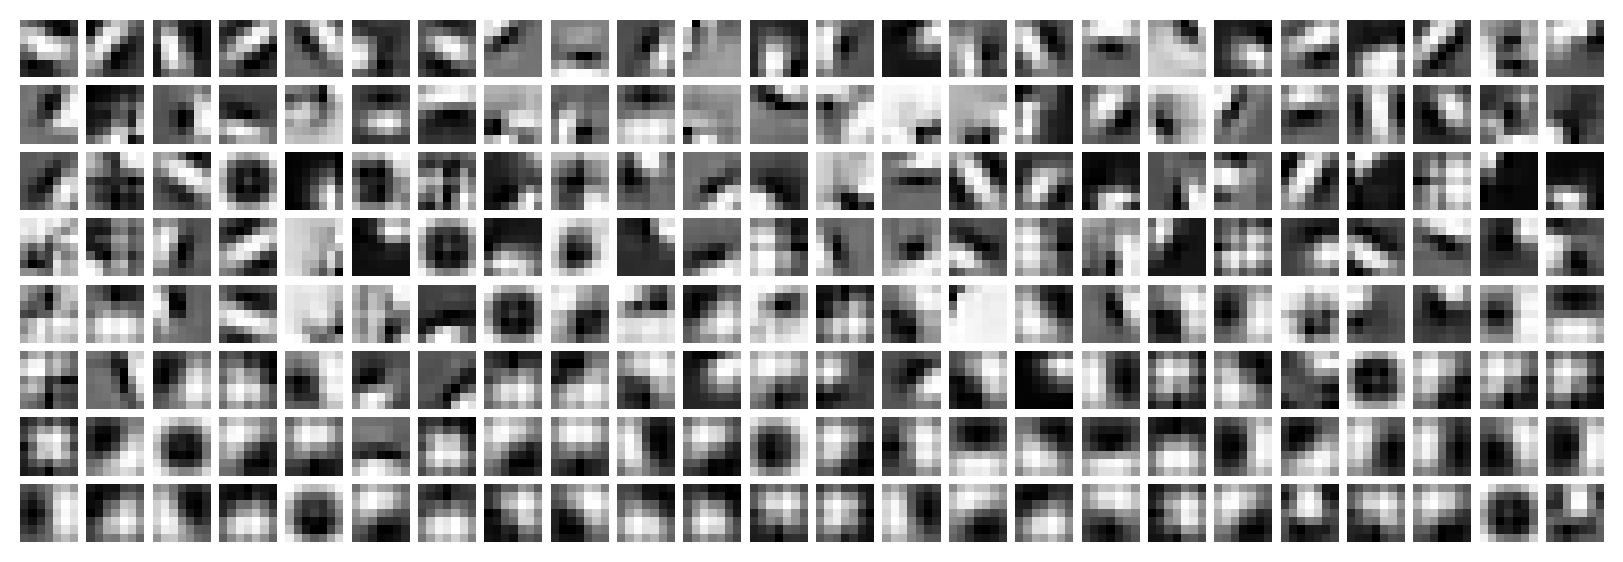

In [15]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), method='min-max');

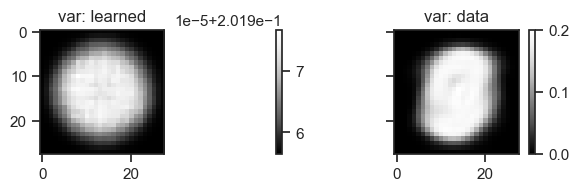

learned inner learning rates (dt):

(tensor([0.7632], device='cuda:1', grad_fn=<ExpBackward0>),)

In [16]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_init = (np.exp(2 * log_sigma)).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.feeder_vld.x.var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (6.2, 1.8), sharex='all', sharey='all')
im = axes[0].imshow(var_init.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: learned')
axes[1].set_title('var: data')

plt.show()

# print dt
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")

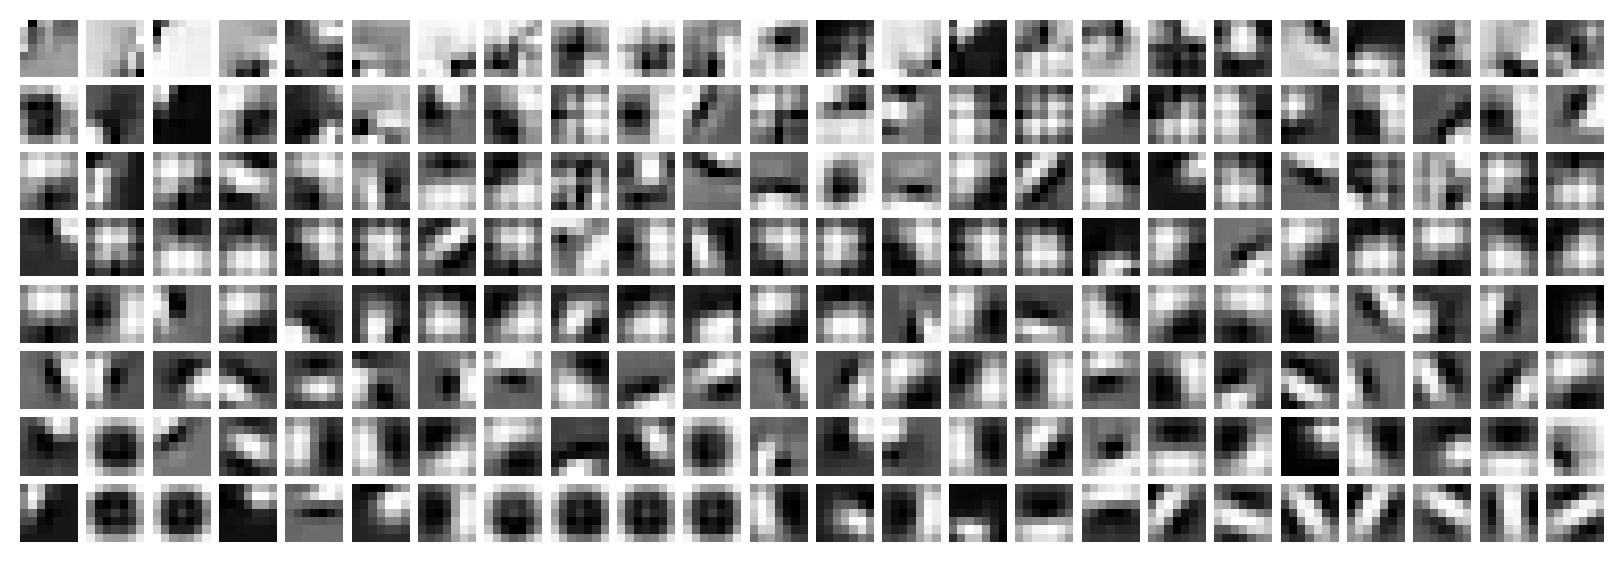

In [17]:
# u0 = tonp(tr.model.layer.u_init[0].squeeze())
# bias = tonp(tr.model.layer.log_bias.squeeze().exp())
weight_norms = tonp(torch.linalg.vector_norm(
    tr.model.layer.get_weight(), dim=(1, 2, 3)))

tr.model.show(order=np.argsort(weight_norms), method='min-max');

## Best 4 stage model that has worked so far

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('MNIST+rotate', model_type, 'ngd|lin')

cfg_vae['t_train'] = 8
cfg_vae['t_tbptt'] = 8
cfg_vae['kl_beta'] = 1.0

cfg_vae['latent_channels'] = 192
cfg_vae['latent_pixels'] = 8
cfg_vae['latent_stride'] = 3

cfg_vae['fwd_ker_u'] = 1
cfg_vae['fwd_ker_z'] = 3

cfg_vae['feeder_cfg'] = {'max_delta_theta': 2.0}
# cfg_vae['clamp_vals'] = {'u': (4.0,), 'du': (4.0,), 'dec': 0.8}

# cfg_vae['recon_mode'] = 'prob'
# cfg_vae['fit_sigma'] = True
# cfg_vae['fit_dt'] = True
# cfg_vae['fit_bias'] = False

cfg_tr['lr'] = 5e-4
cfg_tr['epochs'] = 400
cfg_tr['batch_size'] = 200

cfg_tr['warmup_portion'] = 0.01

In [4]:
model = MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae))
tr = Trainer(model, ConfigTrain(**cfg_tr), device=device)

tr.feeder_trn.n_iters

120000

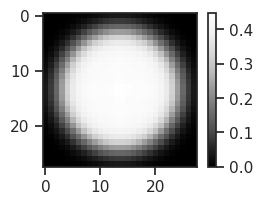

In [5]:
sigma = tr.data_dependent_init(t_total=200, n_data_batches=5, data_batch_sz=5000)
imshow(sigma.squeeze(), cmap='Greys_r')
plt.colorbar();

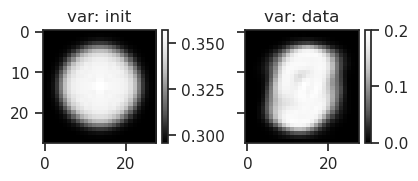

learned inner learning rates (dt):

(tensor([1.], device='cuda:1', grad_fn=<ExpBackward0>),)

In [6]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_init = (np.exp(2 * log_sigma)).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.feeder_vld.x.var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (4.2, 1.7), sharex='all', sharey='all')
im = axes[0].imshow(var_init.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: init')
axes[1].set_title('var: data')

plt.show()

# print dt
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  379.0 K   |
|     ———     |    ———     |
|    layer    |  379.0 K   |
+-------------+------------+

poisson_MNIST+rotate_t-(8,8)_b-1_kms-(192,8,3)_fwd-(1,3)_prob_<ngd|lin>
b200-ep400-lr(0.0005)_temp(0.05)_gr(250)_(2025_09_03,16:55)

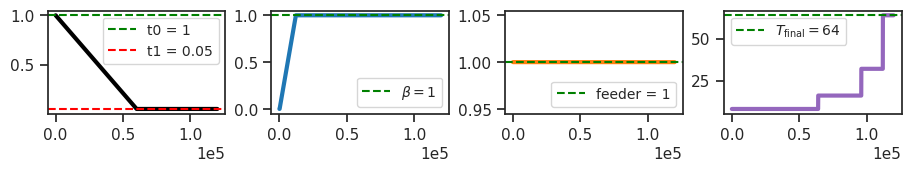

In [7]:
model.print()
tr.print()
tr.show_schedules()

In [8]:
model.layer.n_exp

tensor([50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50,
        50, 50, 50, 50, 50, 50, 50, 50, 50, 50], device='cuda:1',
       dtype=torch.int32)

In [9]:
collections.Counter(tr.t_trains)

Counter({8: 64000, 16: 32000, 32: 16000, 64: 8000})

In [10]:
print(f"\n\n{tr.model.layer}\n\n{tr.model.layer.dec}\n")

PoissonLayer(latent_sz=(192, 8, 8), input_sz=(1, 28, 28), temp=1)

ConvDictionary(in_channels=192, out_channels=1, kernel_size=7, stride=3)

In [11]:
print_num_params(tr.model.layer)

+--------------+------------+
| Module Name  | Num Params |
+--------------+------------+
| PoissonLayer |  379.0 K   |
|     ———      |    ———     |
|    log_dt    |     1      |
|     dec      |   9.4 K    |
|   fwd_z.0    |  331.8 K   |
|   fwd_u.0    |   36.9 K   |
|    u_init    |    192     |
+--------------+------------+

In [12]:
print(f"\n\n{vars(tr.model.cfg)}\n\n{vars(tr.cfg)}\n")

{'prior_log_dist': 'uniform', 'clamp_prior': -4, 't_train': 8, 't_tbptt': 8, 'kl_beta': 1.0, 'latent_channels': 
192, 'latent_pixels': 8, 'latent_stride': 3, 'fwd_ker_u': 1, 'fwd_ker_z': 3, 'enc_type': 'ngd', 'dec_type': 'lin', 
'recon_mode': 'prob', 'dataset': 'MNIST+rotate', 'dataset_name': 'MNIST', 'feeder': 'rotate', 'feeder_cfg': 
{'max_delta_theta': 2.0, 'theta_0': None, 'anneal_portion': 0.0}, 'input_sz': (1, 28, 28), 'latent_sz': (192, 8, 
8), 'init_dist': 'normal', 'init_scale': 0.0001, 'clamp_vals': {'u': (4.0,), 'du': (4.0,), 'dec': 0.8}, 
'stochastic': True, 'optim_sigma': False, 'fit_sigma': True, 'fit_prior': True, 'fit_bias': False, 'fit_dt': True, 
'seed': 0, 'track_stats': False, 'base_dir': '/home/hadi/Projects/TemporalSC', 'data_dir': '/home/hadi/Datasets', 
'runs_dir': 
'/home/hadi/Projects/TemporalSC/runs/poisson_MNIST+rotate_t-(8,8)_b-1_kms-(192,8,3)_fwd-(1,3)_prob_<ngd|lin>', 
'mods_dir': 
'/home/hadi/Projects/TemporalSC/models/poisson_MNIST+rotate_t-(8,8)_b-1_kms-(192,8,3)_fwd-(1,3)_prob_<ngd|lin>', 
'results_dir': '/home/hadi/Projects/TemporalSC/results'}

{'lr': 0.0005, 'epochs': 400, 'batch_size': 200, 'dataset_kws': None, 'warm_restart': 0, 'warmup_portion': 0.01, 
'optimizer': 'adamax_fast', 'optimizer_kws': {'weight_decay': 0.0001, 'betas': (0.9, 0.999), 'eps': 1e-08}, 
'scheduler_type': 'cosine', 'scheduler_kws': {'T_max': 396.0, 'eta_min': 5e-08}, 'ema_rate': None, 'grad_clip': 
250, 'chkpt_freq': 20, 'eval_freq': 20, 'log_freq': 10, 'kl_beta_min': 0.0001, 'kl_const_portion': 0.001, 
'kl_anneal_portion': 0.1, 'temp_anneal_portion': 0.5, 'temp_anneal_type': 'lin', 'temp_start': 1.0, 'temp_stop': 
0.05}

In [13]:
comment = '_'.join([
    f"fwd:u{tr.model.cfg.fwd_ker_u}+z{tr.model.cfg.fwd_ker_z}",
    f"fit:{'dt' if tr.model.cfg.fit_dt else ''}+{'sig' if tr.model.cfg.fit_sigma else ''}",
    f"ClampDec-{tr.model.cfg.clamp_vals['dec']}",
    'datadepinit',
    'stages4-geometric',
    'warmup-0.01',
])
print(comment)

fwd:u1+z3_fit:dt+sig_ClampDec-0.8_datadepinit_stages4-geometric_warmup-0.01

In [14]:
tr.train(comment=comment)

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Warning: Could not save code info: Reference at 'refs/heads/main' does not exist

Warning: Could not save notebook info: Can't identify the notebook path.

epoch # 400, avg loss: 100.813: 100%|█████| 400/400 [20:26:39<00:00, 184.00s/it]


## observe:

4 stages (geometric): help or hurt?

Trying to reproduce these:

- (best fit) https://wandb.ai/yateslab/_TemporalSC/runs/dvyetrxh/overview
- (recent good fit with fwd(1+3)): https://wandb.ai/yateslab/_TemporalSC/runs/61a6a7yh?nw=nwuservafaii

In [15]:
print(model.layer.n_exp)

tensor([17, 38, 43, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 43, 43, 44,
        44, 44, 44, 44, 43, 43, 44, 44, 44, 44, 44, 43, 43, 43, 44, 44, 44, 44,
        44, 43, 43, 44, 44, 44, 44, 44, 44, 44, 44, 43, 44, 43, 44, 44, 44, 44,
        44, 44, 44, 44, 44, 43, 44, 44, 44, 44], device='cuda:1',
       dtype=torch.int32)

100%|███████████████████████████████████| 5/5 [00:12<00:00,  2.53s/it]


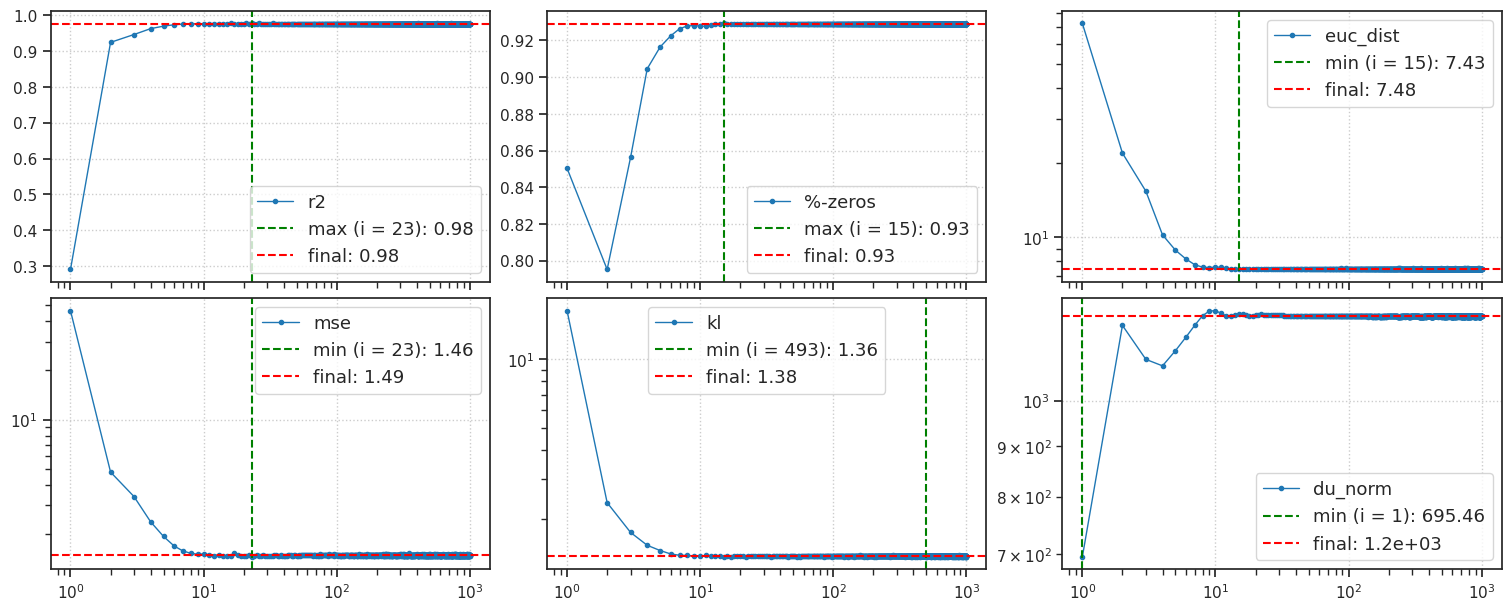

CPU times: user 13.5 s, sys: 8 ms, total: 13.5 s
Wall time: 13.5 s


In [16]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=5)
_ = plot_convergence(results=results, color='C0')

100%|█████████████████████████████████| 50/50 [02:04<00:00,  2.49s/it]


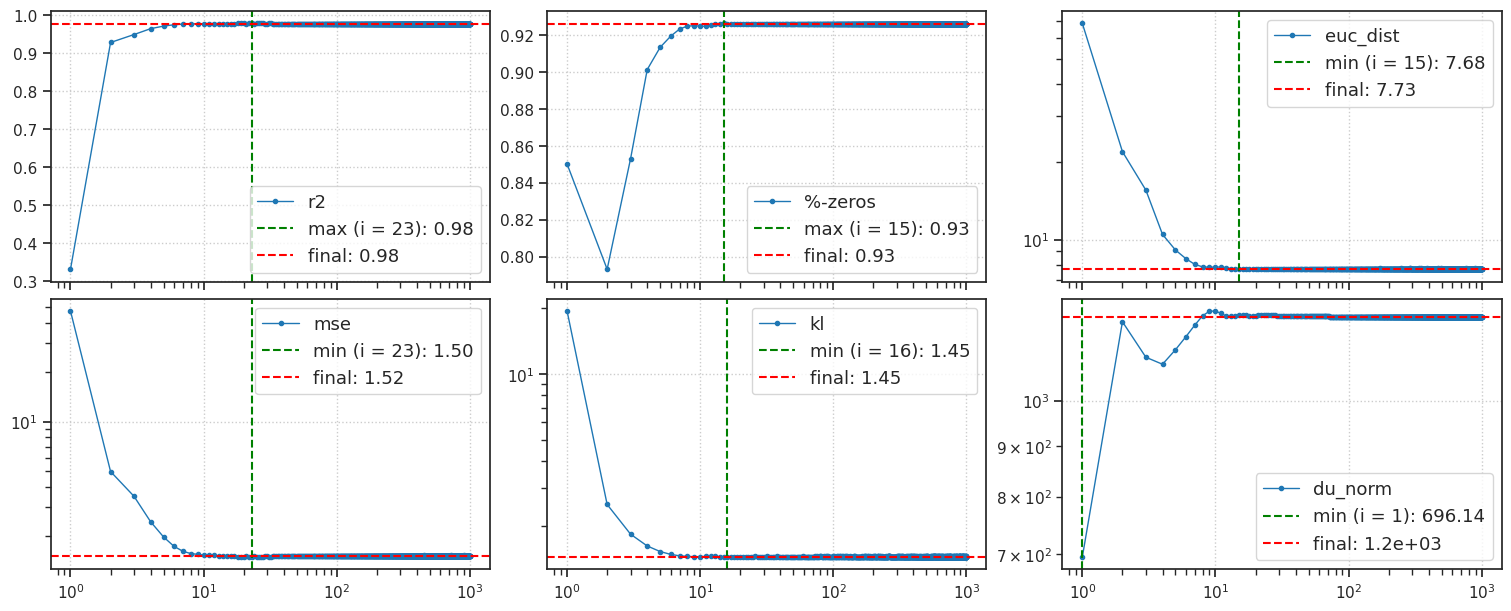

CPU times: user 2min 5s, sys: 104 ms, total: 2min 5s
Wall time: 2min 5s


In [17]:
%%time

results = tr.analysis('vld', t_total=1000, n_data_batches=-1)
_ = plot_convergence(results=results, color='C0')

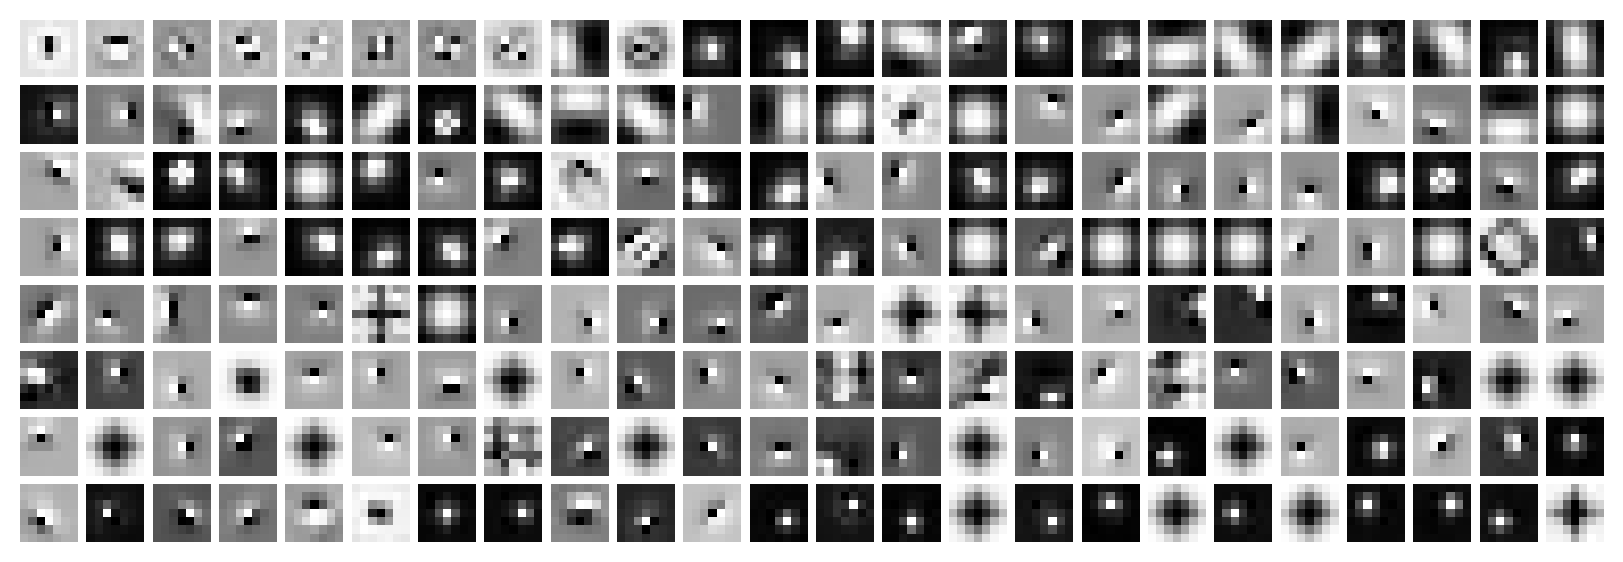

In [18]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
tr.model.show(order=np.argsort(u0), method='min-max');

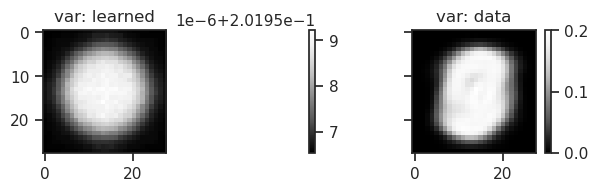

learned inner learning rates (dt):

(tensor([0.2646], device='cuda:1', grad_fn=<ExpBackward0>),)

In [19]:
# get var: learned & data
log_sigma = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_init = (np.exp(2 * log_sigma)).reshape(tr.model.cfg.input_sz)
var_data = tonp(tr.feeder_vld.x.var(dim=0))

# plot
fig, axes =  create_figure(1, 2, (6.2, 1.8), sharex='all', sharey='all')
im = axes[0].imshow(var_init.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data.mean(0), cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

axes[0].set_title('var: learned')
axes[1].set_title('var: data')

plt.show()

# print dt
lr_inner = tuple(dt.exp() for dt in tr.model.layer.log_dt)
print(f"learned inner learning rates (dt):\n\n{lr_inner}\n")

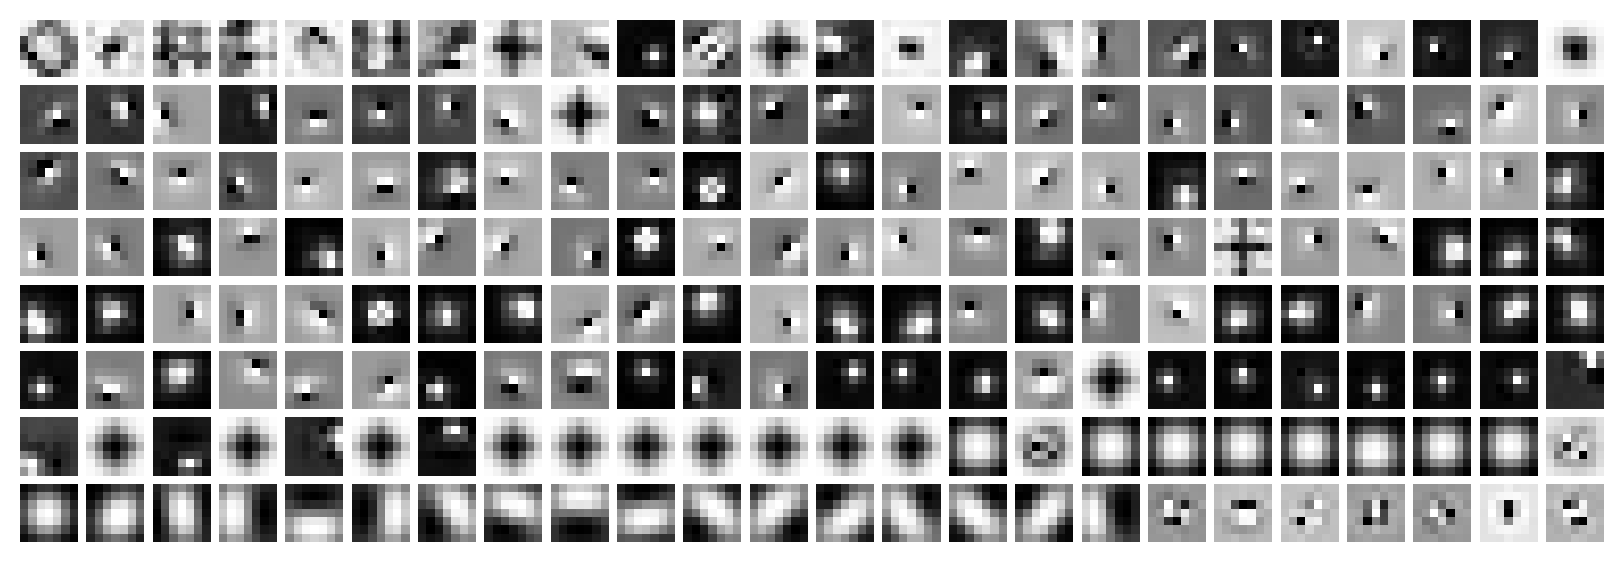

In [20]:
# u0 = tonp(tr.model.layer.u_init[0].squeeze())
# bias = tonp(tr.model.layer.log_bias.squeeze().exp())
weight_norms = tonp(torch.linalg.vector_norm(
    tr.model.layer.get_weight(), dim=(1, 2, 3)))

tr.model.show(order=np.argsort(weight_norms), method='min-max');